In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [9]:
#import the libraries
import numpy as np
import pandas as pd
import sklearn

In [10]:
data = pd.DataFrame({'Price_USA':[80,50,140,25],
                     'Price_INR':[5000,7000,12000,3000]})
data

,Price_USA,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [11]:
#We will perform mathematical wise
data['Price_USA_minmax'] = (data['Price_USA'] - data['Price_USA'].min()) / (data['Price_USA'].max() - data['Price_USA'].min())
data

,Price_USA,Price_INR,Price_USA_minmax
0,80,5000,0.478261
1,50,7000,0.217391
2,140,12000,1.000000
3,25,3000,0.000000


In [12]:
#We will perform mathematical wise
data['Price_INR_minmax'] = (data['Price_INR'] - data['Price_INR'].min()) / (data['Price_INR'].max() - data['Price_INR'].min())
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax
0,80,5000,0.478261,0.222222
1,50,7000,0.217391,0.444444
2,140,12000,1.000000,1.000000
3,25,3000,0.000000,0.000000


In [73]:
import sklearn

In [74]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [15]:
min_max = MinMaxScaler()

In [16]:
#we need to use fit_transform()
data['Price_USA_minsk'] = min_max.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk
0,80,5000,0.478261,0.222222,0.478261
1,50,7000,0.217391,0.444444,0.217391
2,140,12000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000


#Standardization(StandardScalar) = x(i) - mean/std

In [17]:
data['Price_USA_std'] = (data['Price_USA'] - data['Price_USA'].mean()) / (data['Price_USA'].std())
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_USA_std
0,80,5000,0.478261,0.222222,0.478261,0.126108
1,50,7000,0.217391,0.444444,0.217391,-0.479212
2,140,12000,1.000000,1.000000,1.000000,1.336748
3,25,3000,0.000000,0.000000,0.000000,-0.983645


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
data['Price_USA_scaler']=scaler.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_USA_std,Price_USA_scaler
0,80,5000,0.478261,0.222222,0.478261,0.126108,0.145617
1,50,7000,0.217391,0.444444,0.217391,-0.479212,-0.553346
2,140,12000,1.000000,1.000000,1.000000,1.336748,1.543544
3,25,3000,0.000000,0.000000,0.000000,-0.983645,-1.135815


In [21]:
data['Price_INR_scaler']=scaler.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_USA_std,Price_USA_scaler,Price_INR_scaler
0,80,5000,0.478261,0.222222,0.478261,0.126108,0.145617,-0.523205
1,50,7000,0.217391,0.444444,0.217391,-0.479212,-0.553346,0.074744
2,140,12000,1.000000,1.000000,1.000000,1.336748,1.543544,1.569614
3,25,3000,0.000000,0.000000,0.000000,-0.983645,-1.135815,-1.121153


In [22]:
from sklearn.preprocessing import RobustScaler

In [23]:
robust = RobustScaler()

In [24]:
data['Price_USA_robust'] = robust.fit_transform(data[['Price_USA']])
data['Price_USA_robust']
data['Price_INR_robust'] = robust.fit_transform(data[['Price_INR']])
data['Price_INR_robust']

0   -0.266667
1    0.266667
2    1.600000
3   -0.800000
Name: Price_INR_robust, dtype: float64

In [25]:
##Regression on Case Study related to predicting Miles Per Gallon (mpg)
#Scenario as follows:

A Fleet manager wanted to calculate (predict) the mpg efficiently of his vehicles based on (cylinders,weight,displacement,accerlation,horsepower)...

We will be UCIML repo package to fetch, load and transform the data from UCI rep

SyntaxError: invalid syntax (3856575672.py, line 4)

In [26]:
!pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable


In [27]:
!where python

C:\Python314\python.exe
C:\Users\asus\AppData\Local\Programs\Python\Python311\python.exe
C:\Users\asus\AppData\Local\Python\bin\python.exe


In [28]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [29]:
from ucimlrepo import fetch_ucirepo

In [30]:
%pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [34]:
##Step1 : Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
sns.set_style(style='whitegrid') #background style of graphs

In [83]:
#STEP-02: Loading And Cleaning the Data (autompg dataset)
data = fetch_ucirepo(id = 9)
data
x = data.data.features.copy()  #it returs all nummerical features
y = data.data.targets['mpg']
x

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [50]:
x

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [51]:
data

{'data': {'ids':                       car_name
  0    chevrolet,chevelle,malibu
  1            buick,skylark,320
  2           plymouth,satellite
  3                amc,rebel,sst
  4                  ford,torino
  ..                         ...
  393            ford,mustang,gl
  394                  vw,pickup
  395              dodge,rampage
  396                ford,ranger
  397                 chevy,s-10
  
  [398 rows x 1 columns],
  'features':      displacement  cylinders  horsepower  weight  acceleration  model_year  \
  0           307.0          8       130.0    3504          12.0          70   
  1           350.0          8       165.0    3693          11.5          70   
  2           318.0          8       150.0    3436          11.0          70   
  3           304.0          8       150.0    3433          12.0          70   
  4           302.0          8       140.0    3449          10.5          70   
  ..            ...        ...         ...     ...           ...    

In [52]:
x.describe()
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [53]:
x['origin'].unique();
x['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [60]:
#first we will transform the horsepower and origin columns
x['horsepower'] = pd.to_numeric(x['horsepower'],errors='coerce')
#x['horsepower'].info()
x['origin'] = x['origin'].astype(str)

In [68]:
x.info();
numerical_features = ['cylinders','displacement','horsepower','weight',
                      'acceleration','model_year']
categorical_features = ['origin']
x = x[numerical_features+categorical_features]
x.info()
#x.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 21.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 n

In [69]:
#Step3 : Quick Exploratory Data Analysis (Seaborn)
df = x.copy()
df['mpg'] = y
#here we are mapping input and target variable into the dataframe

<Axes: xlabel='mpg', ylabel='Count'>

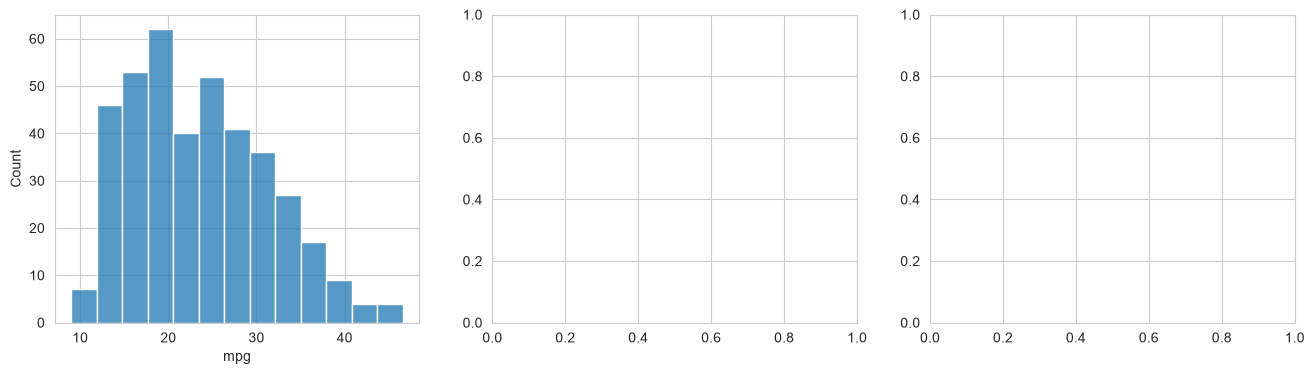

In [71]:
#we are gonna use sunplats() concept to divide the plot into multiple plots
fig,axes = plt.subplots(1,3,figsize=(16,4))
#plot graphs as per axes
sns.histplot(df['mpg'],kde=False,ax=axes[0])

Text(0.5, 1.0, 'Horsepower vs MPG Distribution')

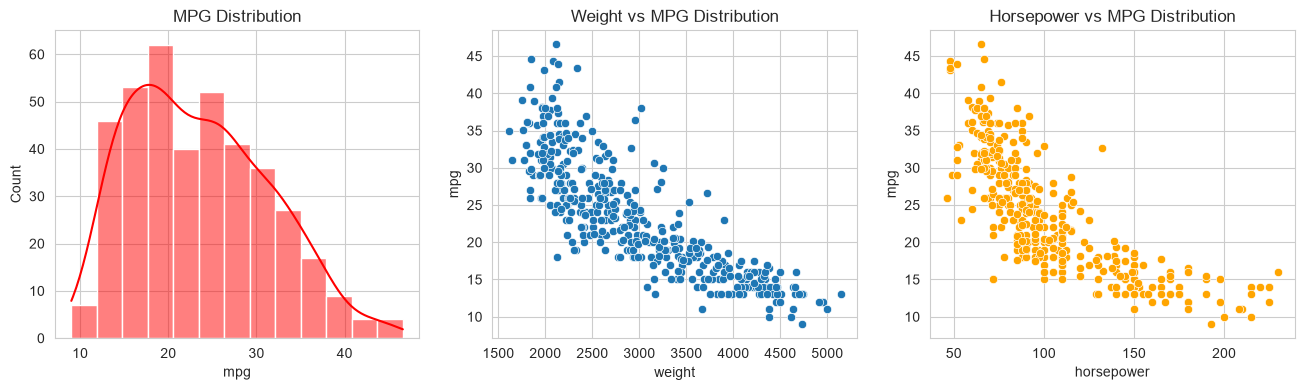

In [77]:
#df
#we are gonna use sunplots() concept to divide the plot into multiple plots
fig,axes = plt.subplots(1,3,figsize=(16,4))
#plot graphs as per axes
sns.histplot(df['mpg'],kde=True,ax=axes[0],color='red')
#in similar way we display other graphs in rmg plots
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'],y=df['mpg'],ax=axes[1])
axes[1].set_title("Weight vs MPG Distribution")
sns.scatterplot(x=df['horsepower'],y=df['mpg'],ax=axes[2],color='orange')
axes[2].set_title("Horsepower vs MPG Distribution")

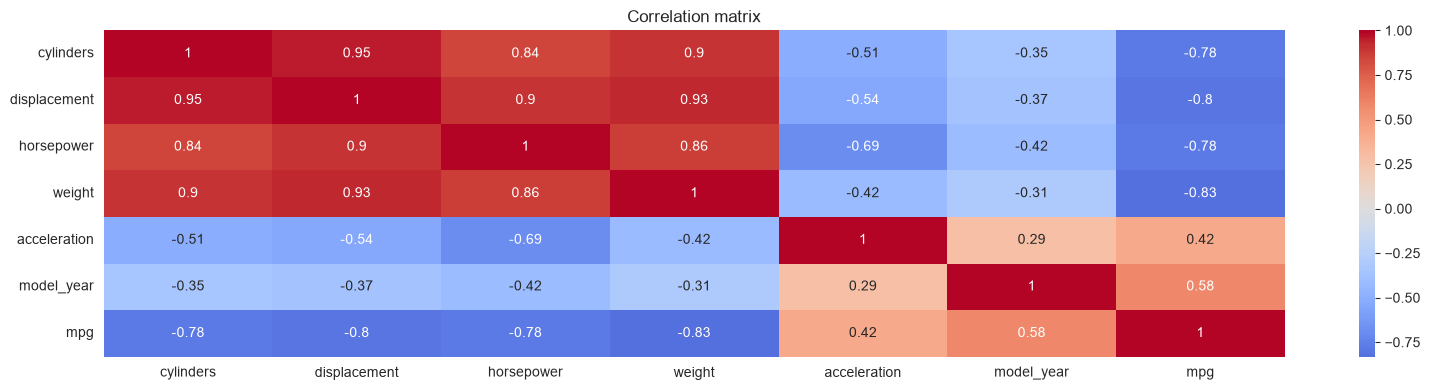

In [79]:
#Correclation between our variables
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            center=0
           )
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [82]:
#Step4: Dividing the data into train test split
#print(x)
#print(y)
#SPlit rule -->70-30,80-20,75-25
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print('\nTrain test Split')
print("Training Data",len(x_train))
print("Testing Data",len(x_test))
#print(x_train)


Train test Split
Training Data 318
Testing Data 80


In [96]:
#Step 5 : Creating a Evaluation Function for baseline model
def evaluate(model_name,actual,predicted):
    """Returns MAE,MSE,RMSE,R2-Score"""
    mse = mean_squared_error(actual,predicted)
    return {'Model_Name': model_name,
    'MAE':mean_absolute_error,
    'MSE':mse,
    'RMSE':np.sqrt(mse),
    'R2-Score':r2_score(actual,predicted)}
results =[]

In [97]:
#Step 6 : Baseline model --->It predicts the training set for every values
baseline_predictions =np.full(len(y_test),y_train.mean())
#baseline_predictions
#in above case we are keeping a baseline prediction
results.append(evaluate("Mean Baseline",y_test,baseline_predictions))
#results
#in the above case we are creating the baseline predicted data

In [102]:
#Step7: We apply Linear Regression
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(x_train[['weight']],y_train)
simple_model_predictions = simple_model.predict(x_test[['weight']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:Weight",y_test,
                        simple_model_predictions))
print(len(results))

5


In [103]:
results

[{'Model_Name': 'Mean Baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, 

In [104]:
import os
print(os.getcwd())

C:\Users\asus
